<a href="https://colab.research.google.com/github/rudzz1950/Remote_sensing/blob/main_2/Copy_of_Building_det.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Project Architecture


In [1]:
!git clone https://github.com/ultralytics/ultralytics.git  # Clone YOLOv8 repo
!cd ultralytics

!pip install ultralytics
!pip install torch torchvision numpy opencv-python matplotlib grad-cam ultralytics


Cloning into 'ultralytics'...
remote: Enumerating objects: 54089, done.
remote: Counting objects: 100% (29/29), done.
remote: Compressing objects: 100% (24/24), done.
remote: Total 54089 (delta 11), reused 6 (delta 5), pack-reused 54060 (from 1)
Receiving objects: 100% (54089/54089), 30.27 MiB | 19.34 MiB/s, done.
Resolving deltas: 100% (40102/40102), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 976.9/976.9 kB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 66.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 48.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.9 MB/s eta 0:00:00
 

1. Input image
https://drive.google.com/file/d/1HFFAzC9S3yl8BtZ0WZGwt5h_HuK8OHdx/view?usp=sharing

2. Output image
https://drive.google.com/file/d/1fYcPXh60cLzIE1CLh0k6yNe89TAR7Ja6/view?usp=sharing

## Implementation

In [2]:
import torch
from ultralytics import YOLO
from IPython.display import clear_output

# Check PyTorch and CUDA
device = "CUDA" if torch.cuda.is_available() else "CPU"
print(f"Setup complete. Using torch {torch.__version__} on {device}")

# Load a YOLOv8 model to test
model = YOLO("yolov8n.pt")  # Load the nano model
print("YOLOv8 model loaded successfully!")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Setup complete. Using torch 2.6.0+cu124 on CUDA


100%|██████████| 6.25M/6.25M [00:00<00:00, 105MB/s]

YOLOv8 model loaded successfully!


In [3]:
# Install Roboflow
!pip install roboflow

# Import required libraries
from roboflow import Roboflow

# Initialize Roboflow with API key
rf = Roboflow(api_key="iMVOMaxCVf9Q6wQNbSnb")

# Load the original house_alloc project
project_house = rf.workspace("quantela").project("house_alloc")
version_house = project_house.version(17)
dataset_house = version_house.download("yolov8")
print("House allocation dataset downloaded successfully!")

# Load the new tree-seg project
project_tree = rf.workspace("test-4udyq").project("tree-seg")
version_tree = project_tree.version(1)  # Assuming version 1, adjust if different
dataset_tree = version_tree.download("yolov8")
print("Tree segmentation dataset downloaded successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.5/84.5 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 79.3 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.11.0.86
    Uninstalling opencv-python-headless-4.11.0.86:
      Successfully uninstalled opencv-python-headless-4.11.0.86
  Attempting uninstall: idna
    Found existing installation: idna 3.10
    Uninstalling idna-3.10:
      Successfully uninstalled idna-3.10


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to House_alloc-17 in yolov8:: 100%|██████████| 18236/18236 [00:02<00:00, 7061.82it/s]

House allocation dataset downloaded successfully!
loading Roboflow workspace...


loading Roboflow project...



Extracting Dataset Version Zip to tree-seg-1 in yolov8:: 100%|██████████| 1488/1488 [00:00<00:00, 7114.08it/s]

Tree segmentation dataset downloaded successfully!


In [4]:
import os

# Define base paths for both datasets
base_path_house = '/content/house_alloc-17'  # Adjust to match your house dataset
base_path_tree = '/content/tree-seg-1'      # Adjust to match your tree dataset

# Define all required subdirectories
subdirs = [
    'train/images',
    'train/labels',
    'valid/images',
    'valid/labels',
    'test/images',
    'test/labels'
]

# Create directories for house dataset
try:
    for subdir in subdirs:
        dir_path = os.path.join(base_path_house, subdir)
        os.makedirs(dir_path, exist_ok=True)
    print("Directories for house YOLOv8 dataset created successfully!")
except Exception as e:
    print(f"Failed to create house directories: {e}")

# Create directories for tree dataset
try:
    for subdir in subdirs:
        dir_path = os.path.join(base_path_tree, subdir)
        os.makedirs(dir_path, exist_ok=True)
    print("Directories for tree YOLOv8 dataset created successfully!")
except Exception as e:
    print(f"Failed to create tree directories: {e}")

# Verify the structure
print("Created directory structure for house dataset:")
for subdir in subdirs:
    print(f"- {os.path.join(base_path_house, subdir)}")

print("Created directory structure for tree dataset:")
for subdir in subdirs:
    print(f"- {os.path.join(base_path_tree, subdir)}")

Directories for house YOLOv8 dataset created successfully!
Directories for tree YOLOv8 dataset created successfully!
Created directory structure for house dataset:
- /content/house_alloc-17/train/images
- /content/house_alloc-17/train/labels
- /content/house_alloc-17/valid/images
- /content/house_alloc-17/valid/labels
- /content/house_alloc-17/test/images
- /content/house_alloc-17/test/labels
Created directory structure for tree dataset:
- /content/tree-seg-1/train/images
- /content/tree-seg-1/train/labels
- /content/tree-seg-1/valid/images
- /content/tree-seg-1/valid/labels
- /content/tree-seg-1/test/images
- /content/tree-seg-1/test/labels


In [ ]:
# base_path = '/content/house_alloc-17'  # Match your Roboflow download

-------------------------------------------------------------


In [ ]:
# # Fix locale encoding
# import locale
# locale.getpreferredencoding = lambda: "UTF-8"

# # Your original code
# dataset_location = dataset.location
# %cat {dataset_location}/data.yaml

# # This is the YAML file Roboflow wrote for us that we're loading into this notebook with our data
# dataset_location = dataset.location
# %cat {dataset_location}/data.yaml

names:
- Houses
nc: 1
roboflow:
  license: CC BY 4.0
  project: house_alloc
  url: https://universe.roboflow.com/quantela/house_alloc/dataset/17
  version: 17
  workspace: quantela
test: ../test/images
train: ../train/images
val: ../valid/images
names:
- Houses
nc: 1
roboflow:
  license: CC BY 4.0
  project: house_alloc
  url: https://universe.roboflow.com/quantela/house_alloc/dataset/17
  version: 17
  workspace: quantela
test: ../test/images
train: ../train/images
val: ../valid/images


In [5]:
import yaml
import os

# Fix locale encoding
import locale
locale.getpreferredencoding = lambda: "UTF-8"

# Dataset locations
dataset_location_house = dataset_house.location  # e.g., '/content/house_alloc-17'
dataset_location_tree = dataset_tree.location    # e.g., '/content/tree-seg-1'

# YAML paths
yaml_path_house = os.path.join(dataset_location_house, 'data.yaml').replace("\\", "/")
yaml_path_tree = os.path.join(dataset_location_tree, 'data.yaml').replace("\\", "/")

# Update house YAML
with open(yaml_path_house, 'r') as f:
    data_house = yaml.safe_load(f)
data_house['train'] = 'train/images'
data_house['val'] = 'valid/images'
data_house['test'] = 'test/images'
with open(yaml_path_house, 'w') as f:
    yaml.safe_dump(data_house, f)
print("House YAML updated!")

# Update tree YAML
with open(yaml_path_tree, 'r') as f:
    data_tree = yaml.safe_load(f)
data_tree['train'] = 'train/images'
data_tree['val'] = 'valid/images'
data_tree['test'] = 'test/images'
with open(yaml_path_tree, 'w') as f:
    yaml.safe_dump(data_tree, f)
print("Tree YAML updated!")

# Verify
print("House YAML:")
!cat {yaml_path_house}
print("Tree YAML:")
!cat {yaml_path_tree}

House YAML updated!
Tree YAML updated!
House YAML:
names:
- Houses
nc: 1
roboflow:
  license: CC BY 4.0
  project: house_alloc
  url: https://universe.roboflow.com/quantela/house_alloc/dataset/17
  version: 17
  workspace: quantela
test: test/images
train: train/images
val: valid/images
Tree YAML:
names:
- Tree
- Tree-canopy
- green-zone
nc: 3
roboflow:
  license: CC BY 4.0
  project: tree-seg
  url: https://universe.roboflow.com/test-4udyq/tree-seg/dataset/1
  version: 1
  workspace: test-4udyq
test: test/images
train: train/images
val: valid/images


In [6]:
!ls /content/ultralytics/ultralytics/cfg/models/v8/

yoloe-v8-seg.yaml	   yolov8-ghost-p2.yaml  yolov8-p6.yaml       yolov8-seg.yaml
yoloe-v8.yaml		   yolov8-ghost-p6.yaml  yolov8-pose-p6.yaml  yolov8-worldv2.yaml
yolov8-cls-resnet101.yaml  yolov8-ghost.yaml	 yolov8-pose.yaml     yolov8-world.yaml
yolov8-cls-resnet50.yaml   yolov8-obb.yaml	 yolov8-rtdetr.yaml   yolov8.yaml
yolov8-cls.yaml		   yolov8-p2.yaml	 yolov8-seg-p6.yaml


In [7]:
# This is the model configuration we will use for our tutorial
%cat /content/ultralytics/ultralytics/cfg/models/v8/yolov8-seg.yaml

# Ultralytics 🚀 AGPL-3.0 License - https://ultralytics.com/license

# Ultralytics YOLOv8-seg instance segmentation model with P3/8 - P5/32 outputs
# Model docs: https://docs.ultralytics.com/models/yolov8
# Task docs: https://docs.ultralytics.com/tasks/segment

# Parameters
nc: 80 # number of classes
scales: # model compound scaling constants, i.e. 'model=yolov8n-seg.yaml' will call yolov8-seg.yaml with scale 'n'
  # [depth, width, max_channels]
  n: [0.33, 0.25, 1024]
  s: [0.33, 0.50, 1024]
  m: [0.67, 0.75, 768]
  l: [1.00, 1.00, 512]
  x: [1.00, 1.25, 512]

# YOLOv8.0n backbone
backbone:
  # [from, repeats, module, args]
  - [-1, 1, Conv, [64, 3, 2]] # 0-P1/2
  - [-1, 1, Conv, [128, 3, 2]] # 1-P2/4
  - [-1, 3, C2f, [128, True]]
  - [-1, 1, Conv, [256, 3, 2]] # 3-P3/8
  - [-1, 6, C2f, [256, True]]
  - [-1, 1, Conv, [512, 3, 2]] # 5-P4/16
  - [-1, 6, C2f, [512, True]]
  - [-1, 1, Conv, [1024, 3, 2]] # 7-P5/32
  - [-1, 3, C2f, [1024, True]]
  - [-1, 1, SPPF, [1024, 5]] # 9

# YOLOv8.0n

In [8]:
# Register the custom writetemplate magic
from IPython.core.magic import register_line_cell_magic

@register_line_cell_magic
def writetemplate(line, cell):
    with open(line, 'w') as f:
        f.write(cell.format(**globals()))

# Set number of classes
num_classes_house = 1  # For 'Houses' from house_alloc-17
num_classes_tree = 1   # Adjust based on tree-seg dataset (check data.yaml for 'names')

# House YOLOv8m custom config
config_text_house = f"""# YOLOv8 medium custom config for house detection
nc: {num_classes_house}  # Number of classes (1 for Houses)
depth_multiple: 0.67  # Model depth multiple (medium scale)
width_multiple: 0.75  # Layer channel multiple (medium scale)

# Backbone
backbone:
  - [-1, 1, Conv, [64, 3, 2]]  # 0-P1/2
  - [-1, 1, Conv, [128, 3, 2]]  # 1-P2/4
  - [-1, 3, C2f, [128, True]]   # 2
  - [-1, 1, Conv, [256, 3, 2]]  # 3-P3/8
  - [-1, 6, C2f, [256, True]]   # 4
  - [-1, 1, Conv, [512, 3, 2]]  # 5-P4/16
  - [-1, 6, C2f, [512, True]]   # 6
  - [-1, 1, Conv, [1024, 3, 2]] # 7-P5/32
  - [-1, 3, C2f, [1024, True]]  # 8
  - [-1, 1, SPPF, [1024, 5]]    # 9 (SPP block)

# Head
head:
  - [-1, 1, nn.Upsample, [None, 2, 'nearest']]  # 10
  - [[-1, 6], 1, Concat, [1]]  # 11 cat backbone P4
  - [-1, 3, C2f, [512, True]]   # 12
  - [-1, 1, nn.Upsample, [None, 2, 'nearest']]  # 13
  - [[-1, 4], 1, Concat, [1]]  # 14 cat backbone P3
  - [-1, 3, C2f, [256, True]]   # 15 (P3/8-small)
  - [-1, 1, Conv, [256, 3, 2]]  # 16
  - [[-1, 12], 1, Concat, [1]]  # 17 cat head P4
  - [-1, 3, C2f, [512, True]]   # 18 (P4/16-medium)
  - [-1, 1, Conv, [512, 3, 2]]  # 19
  - [[-1, 9], 1, Concat, [1]]  # 20 cat head P5
  - [-1, 3, C2f, [1024, True]]  # 21 (P5/32-large)
  - [[15, 18, 21], 1, Detect, [nc]]  # Detect(P3, P4, P5)
"""

# Tree YOLOv8m custom config
config_text_tree = f"""# YOLOv8 medium custom config for tree segmentation
nc: {num_classes_tree}  # Number of classes (adjust based on tree-seg dataset)
depth_multiple: 0.67  # Model depth multiple (medium scale)
width_multiple: 0.75  # Layer channel multiple (medium scale)

# Backbone
backbone:
  - [-1, 1, Conv, [64, 3, 2]]  # 0-P1/2
  - [-1, 1, Conv, [128, 3, 2]]  # 1-P2/4
  - [-1, 3, C2f, [128, True]]   # 2
  - [-1, 1, Conv, [256, 3, 2]]  # 3-P3/8
  - [-1, 6, C2f, [256, True]]   # 4
  - [-1, 1, Conv, [512, 3, 2]]  # 5-P4/16
  - [-1, 6, C2f, [512, True]]   # 6
  - [-1, 1, Conv, [1024, 3, 2]] # 7-P5/32
  - [-1, 3, C2f, [1024, True]]  # 8
  - [-1, 1, SPPF, [1024, 5]]    # 9 (SPP block)

# Head
head:
  - [-1, 1, nn.Upsample, [None, 2, 'nearest']]  # 10
  - [[-1, 6], 1, Concat, [1]]  # 11 cat backbone P4
  - [-1, 3, C2f, [512, True]]   # 12
  - [-1, 1, nn.Upsample, [None, 2, 'nearest']]  # 13
  - [[-1, 4], 1, Concat, [1]]  # 14 cat backbone P3
  - [-1, 3, C2f, [256, True]]   # 15 (P3/8-small)
  - [-1, 1, Conv, [256, 3, 2]]  # 16
  - [[-1, 12], 1, Concat, [1]]  # 17 cat head P4
  - [-1, 3, C2f, [512, True]]   # 18 (P4/16-medium)
  - [-1, 1, Conv, [512, 3, 2]]  # 19
  - [[-1, 9], 1, Concat, [1]]  # 20 cat head P5
  - [-1, 3, C2f, [1024, True]]  # 21 (P5/32-large)
  - [[15, 18, 21], 1, Detect, [nc]]  # Detect(P3, P4, P5)
"""

# Save the config files
config_path_house = "/content/yolov8m-custom-house.yaml"
with open(config_path_house, "w") as f:
    f.write(config_text_house)
print(f"House config file saved at {config_path_house}")

config_path_tree = "/content/yolov8m-custom-tree.yaml"
with open(config_path_tree, "w") as f:
    f.write(config_text_tree)
print(f"Tree config file saved at {config_path_tree}")

House config file saved at /content/yolov8m-custom-house.yaml
Tree config file saved at /content/yolov8m-custom-tree.yaml


In [10]:
# Update the Ultralytics repo for YOLOv8
!cd /content/ultralytics && git pull

print(dataset_location_house)
print(dataset_location_tree)

import torch
print(torch.cuda.is_available())
print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU found")


Already up to date.
/content/House_alloc-17
/content/tree-seg-1
True
1
Tesla T4


In [11]:
%%time
# Train house model
from ultralytics import YOLO

# Load pretrained YOLOv8m model for house detection
model_house = YOLO("yolov8m-custom-house.yaml").load("yolov8m.pt")  # Load with pre-trained weights

# Train the house model
model_house.train(
    data=f"{dataset_location_house}/data.yaml",  # Path to house dataset config
    epochs=5,                            # Reduced for demo; increase for better results
    imgsz=640,                           # Larger image size for better detection
    batch=16,                            # Batch size suitable for Tesla T4 GPU
    patience=5,                         # Early stopping after 5 epochs of no improvement
    cache="disk",                        # Use disk caching for deterministic results
    device=0,                            # Use GPU (Tesla T4, CUDA:0)
    workers=4,                           # Number of data loader workers
    pretrained=True,                     # Explicitly use pretrained weights
    lr0=0.0005,                          # Lower initial learning rate for stability
    mosaic=1.0,
    augment=True,                        # Enable data augmentation
    name="yolov8m_house_results",
)

# Train tree model
model_tree = YOLO("yolov8m-custom-tree.yaml").load("yolov8m.pt")  # Load with pre-trained weights

# Train the tree model
model_tree.train(
    data=f"{dataset_location_tree}/data.yaml",  # Path to tree dataset config
    epochs=5,                            # Reduced for demo; increase for better results
    imgsz=640,                           # Larger image size for better detection
    batch=16,                            # Batch size suitable for Tesla T4 GPU
    patience=5,                         # Early stopping after 5 epochs of no improvement
    cache="disk",                        # Use disk caching for deterministic results
    device=0,                            # Use GPU (Tesla T4, CUDA:0)
    workers=4,                           # Number of data loader workers
    pretrained=True,                     # Explicitly use pretrained weights
    lr0=0.0005,                          # Lower initial learning rate for stability
    mosaic=1.0,
    augment=True,                        # Enable data augmentation
    name="yolov8m_tree_results",
)

# Optional: Validate both models after training
model_house.val()  # Runs validation on the best saved weights for house
model_tree.val()   # Runs validation on the best saved weights for tree

100%|██████████| 49.7M/49.7M [00:00<00:00, 118MB/s]


Transferred 391/475 items from pretrained weights
Ultralytics 8.3.99 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8m-custom-house.yaml, data=/content/House_alloc-17/data.yaml, epochs=5, time=None, patience=5, batch=16, imgsz=640, save=True, save_period=-1, cache=disk, device=0, workers=4, project=None, name=yolov8m_house_results, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=True, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False

100%|██████████| 755k/755k [00:00<00:00, 22.6MB/s]



                   from  n    params  module                                       arguments                     
  0                  -1  1      1392  ultralytics.nn.modules.conv.Conv             [3, 48, 3, 2]                 
  1                  -1  1     41664  ultralytics.nn.modules.conv.Conv             [48, 96, 3, 2]                
  2                  -1  2    111360  ultralytics.nn.modules.block.C2f             [96, 96, 2, True]             
  3                  -1  1    166272  ultralytics.nn.modules.conv.Conv             [96, 192, 3, 2]               
  4                  -1  4    813312  ultralytics.nn.modules.block.C2f             [192, 192, 4, True]           
  5                  -1  1    664320  ultralytics.nn.modules.conv.Conv             [192, 384, 3, 2]              
  6                  -1  4   3248640  ultralytics.nn.modules.block.C2f             [384, 384, 4, True]           
  7                  -1  1   2655744  ultralytics.nn.modules.conv.Conv             [384

100%|██████████| 5.35M/5.35M [00:00<00:00, 78.8MB/s]


...


val: Caching images (0.6GB Disk): 100%|██████████| 538/538 [00:00<00:00, 26032.04it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 34/34 [00:34<00:00,  1.01s/it]


                   all        538       8340      0.391      0.371      0.291      0.102
Speed: 1.0ms preprocess, 53.1ms inference, 0.0ms loss, 3.4ms postprocess per image
Results saved to runs/detect/yolov8m_house_results2
Ultralytics 8.3.99 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8m-custom-tree summary (fused): 92 layers, 33,935,161 parameters, 0 gradients, 85.3 GFLOPs


val: Scanning /content/tree-seg-1/valid/labels.cache... 60 images, 0 backgrounds, 0 corrupt: 100%|██████████| 60/60 [00:00<?, ?it/s]
val: Caching images (0.0GB Disk): 100%|██████████| 60/60 [00:00<00:00, 36215.03it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 4/4 [00:07<00:00,  1.82s/it]


                   all         60        513      0.293      0.432      0.338      0.201
                  Tree         46        182      0.372      0.615      0.463      0.298
           Tree-canopy         60        291      0.359      0.605      0.429      0.228
            green-zone         18         40       0.15      0.075      0.122     0.0777
Speed: 10.1ms preprocess, 58.8ms inference, 0.0ms loss, 13.1ms postprocess per image
Results saved to runs/detect/yolov8m_tree_results2
CPU times: user 23min 41s, sys: 2min 22s, total: 26min 4s
Wall time: 30min 23s


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b8537da7450>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

Saving vellore23.tif to vellore23.tif
Using file: vellore23.tif

0: 640x640 100 Housess, 40.4ms
Speed: 4.1ms preprocess, 40.4ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 5 Trees, 8 Tree-canopys, 2 green-zones, 36.4ms
Speed: 3.7ms preprocess, 36.4ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)


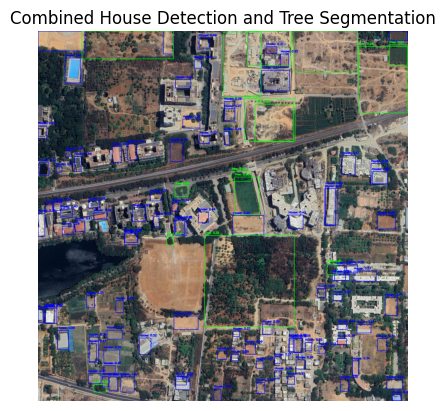

Combined result saved at /content/output/vellore23_combined_output.jpg


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
from google.colab import files
uploaded = files.upload()

img_path = list(uploaded.keys())[0]  # Get the uploaded file name
print("Using file:", img_path)

import os
from ultralytics import YOLO
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import cv2

# Load the input image using PIL and convert to RGB
image = Image.open(img_path).convert("RGB")
image_np = np.array(image)  # Convert to numpy array for processing

# Load trained YOLO models
model_house = YOLO("runs/detect/yolov8m_house_results/weights/best.pt")
model_tree = YOLO("runs/detect/yolov8m_tree_results/weights/best.pt")

# Run inference for both models
results_house = model_house(image_np)
results_tree = model_tree(image_np)

# Define output directory inside Colab
output_dir = "/content/output"
os.makedirs(output_dir, exist_ok=True)  # Create folder if it doesn't exist

# Extract original filename without extension
base_name = os.path.splitext(os.path.basename(img_path))[0]
output_path_combined = os.path.join(output_dir, f"{base_name}_combined_output.jpg")

# Create a copy of the original image for combined output
combined_image = image_np.copy()

# Process house detection results
for r in results_house:
    # Get bounding boxes and labels
    boxes = r.boxes.xyxy.cpu().numpy()  # [x_min, y_min, x_max, y_max]
    confidences = r.boxes.conf.cpu().numpy()
    class_ids = r.boxes.cls.cpu().numpy()

    for box, conf, cls_id in zip(boxes, confidences, class_ids):
        x_min, y_min, x_max, y_max = map(int, box)
        # Draw house bounding box in blue
        cv2.rectangle(combined_image, (x_min, y_min), (x_max, y_max), (0, 0, 255), 2)  # Blue color
        label = f"House: {conf:.2f}"
        cv2.putText(combined_image, label, (x_min, y_min - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)

# Process tree segmentation/detection results
for r in results_tree:
    # Get bounding boxes and labels (assuming detection; adjust for segmentation if needed)
    boxes = r.boxes.xyxy.cpu().numpy()  # [x_min, y_min, x_max, y_max]
    confidences = r.boxes.conf.cpu().numpy()
    class_ids = r.boxes.cls.cpu().numpy()

    for box, conf, cls_id in zip(boxes, confidences, class_ids):
        x_min, y_min, x_max, y_max = map(int, box)
        # Draw tree bounding box in green
        cv2.rectangle(combined_image, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)  # Green color
        label = f"Tree: {conf:.2f}"
        cv2.putText(combined_image, label, (x_min, y_min - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

# Convert combined image back to PIL format and save
combined_image_pil = Image.fromarray(combined_image)
combined_image_pil.save(output_path_combined, format="JPEG", quality=95)

# Display the combined result
plt.imshow(combined_image)
plt.axis("off")
plt.title("Combined House Detection and Tree Segmentation")
plt.show()
print(f"Combined result saved at {output_path_combined}")

# Download the combined image to your local machine
files.download(output_path_combined)

Plot Metrics

# Evaluate Custom YOLOv8 Detector Performance


Training losses and performance metrics are saved to Tensorboard and also to a logfile defined above with the **--name** flag when we train. In our case, we named this `yolov8s_results_80`. (If given no name, it defaults to `results.txt`.) The results file is plotted as a png after training completes.

Note from Glenn: Partially completed `results.txt` files can be plotted with `from utils.utils import plot_results; plot_results()`.

In [ ]:
# Start tensorboard
# Launch after you have started training
%load_ext tensorboard
%tensorboard --logdir runs